In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# First look at dataset
- 10886 rows 
- 12 columns:
    - datetime: str
    - season, holiday, workingday, weahther, casual, registered, count: int64
    - temp, atemp, humidity, windspeed: float64
- no null cells and duplicated rows

In [46]:
df=pd.read_csv(r"..\data\raw\yulu_bike_sharing_dataset.csv")
print(df.head())
print(df.tail)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
cols=df.columns.to_list()
label_col=["datetime", "season", "holiday", "workingday", "weather"]
continuous_col=[i for i in cols if i not in label_col]
print(continuous_col)

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  
<bound method NDFrame.tail of                   datetime  season  holiday  workingday  weather   temp  \
0      2011-01-01 00:00:00       1        0           0        1   9.84   
1      2011-01-01 01:00:00       1     

# check outliers
- temp, atempt: don't have outliers
- humidity: have less outliers
- windspeed, casual, registed, count: have a lot of outliers
- number of outlier rows: 1347 (12,37%)
=> because the percentage of outliers is high and can lead to bias, so I create 2 data set: one is raw with outliers to EDA and one remove outliers; then, using hypothesis testing to compare them later

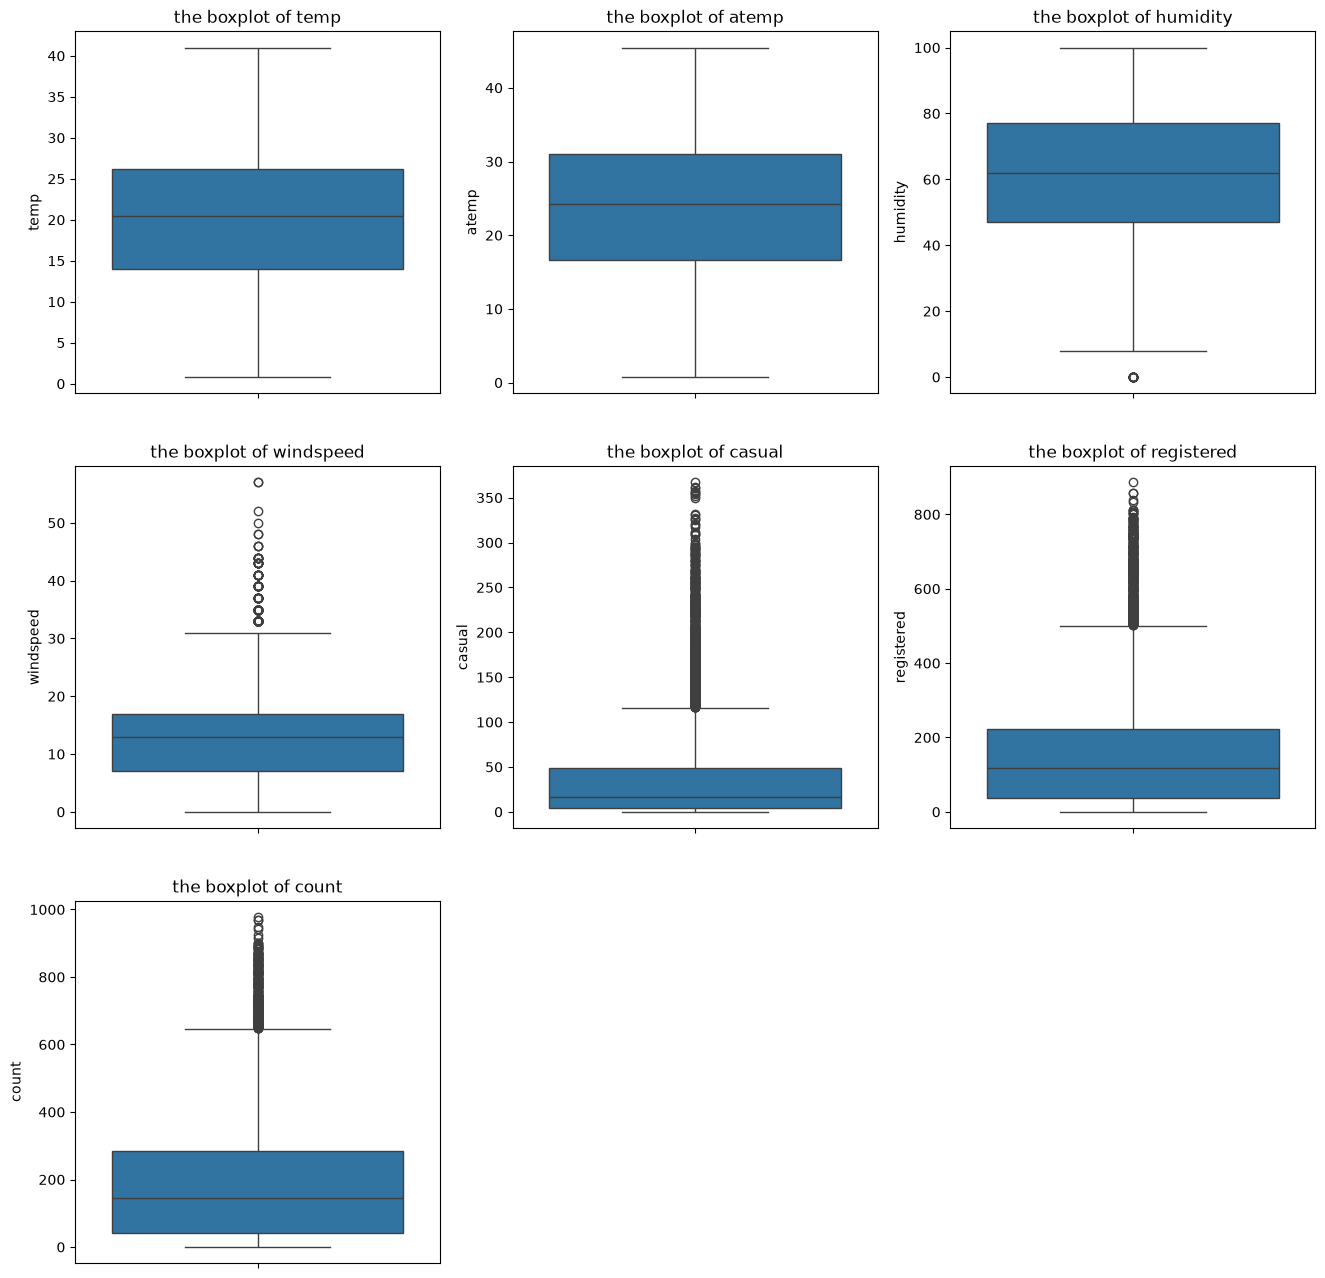

In [ ]:
fig,axes=plt.subplots(3,3,figsize=(16,16))
axes=axes.flatten()
for index, col in enumerate(continuous_col):
    sns.boxplot(y=df[col], ax=axes[index])
    axes[index].set_title(f"the boxplot of {col}")
for j in range(len(continuous_col), len(axes)):
    fig.delaxes(axes[j])
plt.show()

In [54]:
outlier_col=["windspeed", "casual", "registered", "count"]
df_copy=df.copy()
for i in outlier_col:
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    low=Q1-1.5*IQR
    up=Q3+1.5*IQR
    df_copy=df_copy[(df_copy[i]>=low) & (df_copy[i]<=up)]
num_outlier_col=len(df)-len(df_copy)
print(f"the number of outlier rows is {num_outlier_col}")
print(f"the percentage of outlier rows is {num_outlier_col*100/len(df)}")
df_copy.to_csv(r"../data/processed/yulu_bike_remove_outliers.csv", index=False)

the number of outlier rows is 1347
the percentage of outlier rows is 12.37369097923939
